# 02 · Modelling
End-to-end walkthrough of the pipeline implemented in [`src/`](../src). The same steps run from the command line with
`python -m src.train` — this notebook exists to show the intermediate results.

**Approach**
1. Feature engineering (asset age, date parts, hours cleaning) — `src/features.py`
2. Chronological split: oldest 85% train / newest 15% evaluation — `src/data.py`
3. Preprocessing pipelines (leak-free: fit on train only) — `src/preprocess.py`
4. Train on `log1p(TargetValue)`, score with RMSLE
5. Compare model families, then blend CatBoost + LightGBM + XGBoost

In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [3]:
import sys; sys.path.append('..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as cfg
from src.data import load_raw
from src.evaluate import fit_blend_weights, rmsle
from src.models import baseline_models, final_models
from src.preprocess import build_catboost_preprocessor, build_preprocessor
from src.train import prepare_splits

DATA_DIR = '/content/data'   # on Kaggle: /kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge
USE_GPU = False            # set True on a GPU runtime (CatBoost / XGBoost)

## 1. Features and chronological split

In [4]:
train_raw, test_raw = load_raw(DATA_DIR)
X_train, y_train, X_eval, y_eval, reference_date, hours_cap = prepare_splits(train_raw)

print('train', X_train.shape, '| eval', X_eval.shape)
print('train period:', X_train[cfg.DATE_COL].min().date(), '->', X_train[cfg.DATE_COL].max().date())
print('eval  period:', X_eval[cfg.DATE_COL].min().date(), '->', X_eval[cfg.DATE_COL].max().date())
print(f'hours cap (99.5th pct of train): {hours_cap:,.0f}')

/content/src/data.py:19: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(train_path), pd.read_csv(test_path)


train (117716, 52) | eval (20985, 52)
train period: 1990-01-31 -> 2012-02-23
eval  period: 2012-02-24 -> 2013-04-28
hours cap (99.5th pct of train): 38,256


## 2. Preprocessing

In [5]:
pre, cat_pre = build_preprocessor(), build_catboost_preprocessor()
Xtr, Xev = pre.fit_transform(X_train), pre.transform(X_eval)
Xtr_cat, Xev_cat = cat_pre.fit_transform(X_train), cat_pre.transform(X_eval)
y_log = np.log1p(y_train)
print('encoded matrix:', Xtr.shape, '| CatBoost matrix:', Xtr_cat.shape)

encoded matrix: (117716, 98) | CatBoost matrix: (117716, 18)


## 3. Model-family comparison

In [6]:
rows = []
for name, model in baseline_models().items():
    model.fit(Xtr, y_log)
    rows.append({'Model': name, 'eval RMSLE': rmsle(y_eval, np.expm1(model.predict(Xev)))})
baseline_df = pd.DataFrame(rows).sort_values('eval RMSLE').reset_index(drop=True)
baseline_df

,Model,eval RMSLE
0,LightGBM,0.262680
1,XGBoost,0.263793
2,Random Forest,0.284885
3,Decision Tree,0.373172
4,Linear Regression,0.426206


Gradient-boosted trees clearly beat a linear model and a single tree, which suggests strong non-linear interactions between age, usage and the (high-cardinality) specification columns.

## 4. Final models

In [7]:
fitted, eval_preds = {}, {}
for name, model in final_models(gpu=USE_GPU).items():
    if name == 'CatBoost':
        model.fit(Xtr_cat, y_log, cat_features=cfg.CAT_FEATURES); raw = model.predict(Xev_cat)
    else:
        model.fit(Xtr, y_log); raw = model.predict(Xev)
    fitted[name], eval_preds[name] = model, np.clip(np.expm1(raw), 0, None)
    print(f'{name:10s} eval RMSLE: {rmsle(y_eval, eval_preds[name]):.5f}')

CatBoost   eval RMSLE: 0.24082
LightGBM   eval RMSLE: 0.25668
XGBoost    eval RMSLE: 0.26437


## 5. Ensemble — with an honest evaluation of the blend weights
Choosing blend weights on the evaluation rows and then reporting the score on those same rows is optimistic.
Here the weights are fitted on the **first half** of the evaluation window (chronologically) and scored on the **second half**.

In [8]:
names = list(eval_preds)
P = np.column_stack([eval_preds[n] for n in names])
y_eval_arr = y_eval.to_numpy()
mid = len(y_eval_arr) // 2

w_half = fit_blend_weights(P[:mid], y_eval_arr[:mid])
print('weights (fit on 1st half):', dict(zip(names, w_half.round(4))))
print('\nRMSLE on 2nd half')
for i, n in enumerate(names):
    print(f'  {n:10s} {rmsle(y_eval_arr[mid:], P[mid:, i]):.5f}')
print(f'  {"Blend":10s} {rmsle(y_eval_arr[mid:], P[mid:] @ w_half):.5f}')

weights (fit on 1st half): {'CatBoost': np.float64(0.7454), 'LightGBM': np.float64(0.2546), 'XGBoost': np.float64(0.0)}

RMSLE on 2nd half
  CatBoost   0.25024
  LightGBM   0.26846
  XGBoost    0.27682
  Blend      0.24942


## 6. Where the error is
Residuals in log space by price band, to see whether the model is biased for cheap or expensive machines.

In [9]:
w_full = fit_blend_weights(P, y_eval_arr)
blend = P @ w_full
resid = np.log1p(blend) - np.log1p(y_eval_arr)

band = pd.qcut(y_eval_arr, 5, labels=['lowest 20%', '20-40%', '40-60%', '60-80%', 'top 20%'])
pd.Series(resid).groupby(band, observed=True).agg(['mean', lambda s: np.sqrt((s ** 2).mean())]).set_axis(['mean log error (bias)', 'RMSLE'], axis=1)

,mean log error (bias),RMSLE
lowest 20%,0.087005,0.258639
20-40%,-0.039937,0.215156
40-60%,-0.086311,0.235735
60-80%,-0.108231,0.229309
top 20%,-0.176950,0.256382


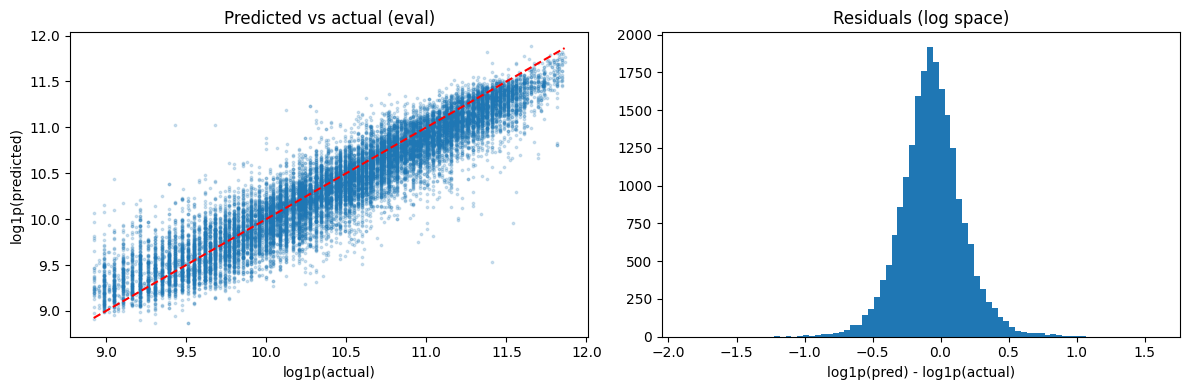

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(np.log1p(y_eval_arr), np.log1p(blend), s=3, alpha=0.2)
lims = [np.log1p(y_eval_arr).min(), np.log1p(y_eval_arr).max()]; ax[0].plot(lims, lims, 'r--')
ax[0].set(xlabel='log1p(actual)', ylabel='log1p(predicted)', title='Predicted vs actual (eval)')
ax[1].hist(resid, bins=80); ax[1].set(title='Residuals (log space)', xlabel='log1p(pred) - log1p(actual)')
plt.tight_layout(); plt.savefig('../content/reports/figures/predicted_vs_actual.png', dpi=150); plt.show()

## 7. Feature importance
CatBoost importance, grouped by feature.

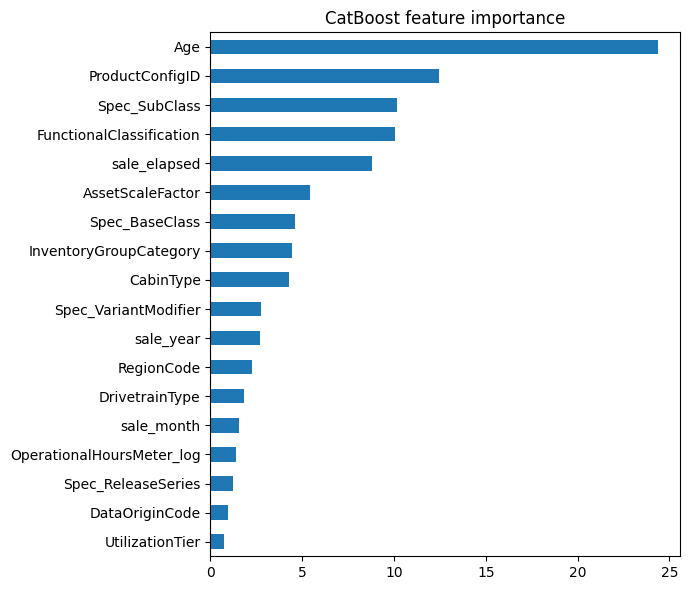

In [14]:
cb = fitted['CatBoost']
imp = pd.Series(cb.get_feature_importance(), index=Xtr_cat.columns).sort_values()
imp.plot(kind='barh', figsize=(7, 6), title='CatBoost feature importance')
plt.tight_layout(); plt.savefig('../content/reports/figures/feature_importance.png', dpi=150); plt.show()

## 8. Submission
Run `python -m src.predict --data-dir data/raw` to write `submissions/submission.csv` using the saved models and weights.